#**CODICE**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

##**FUNZIONI DI UTILITY**

In [ ]:
!pip install mtcnn
import cv2
import numpy as np
import time
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from mtcnn import MTCNN

# --- Funzioni Helper per Colab (Invariate) ---
def _js_to_image(js_reply):
    if not js_reply or 'base64,' not in js_reply: return None
    try:
        image_bytes = b64decode(js_reply.split(',')[1])
        jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
        return cv2.imdecode(jpg_as_np, flags=1)
    except Exception: return None

def _capture_image(quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Cattura Foto';
        div.appendChild(capture);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
      ''')
    display(js)
    try: return _js_to_image(eval_js('takePhoto({})'.format(quality)))
    except Exception: return None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.2 MB/s eta 0:00:00


##**CLASSE**

In [ ]:
# --- Classe BiometricAcquisition Parametrizzata ---
class BiometricAcquisition:
  """
  Classe per l'acquisizione biometrica facciale altamente configurabile.
  """

  def __init__(self, max_attempts=3, blur_threshold=100.0, contrast_threshold=20.0, brightness_range = (40, 220), min_face_size=100):
    """
    Inizializza il sistema di acquisizione con parametri personalizzabili.

    Args:
        max_attempts (int): Numero massimo di tentativi di scatto (Default: 3).
        blur_threshold (float): Soglia minima per la varianza del Laplaciano (Default: 100.0).
        contrast_threshold (float): Soglia minima per il contrasto (Default: 20.0).
        detector (object): Istanza opzionale di un detector pre-inizializzato (es. MTCNN).
    """
    # Configurazione parametri
    self.max_attempts = max_attempts
    self.blur_threshold = blur_threshold
    self.contrast_threshold = contrast_threshold
    self.brightness_range = brightness_range
    self.min_face_size = min_face_size

    self.detector = MTCNN()

    print(f"Face Acquisition inizializzato.")
    print(f"Config: Attempts={self.max_attempts}")
    print(f"Vincoli: MinSize={self.min_face_size}px, Blur_Th={self.blur_threshold}, Contrast_Th={self.contrast_threshold}")


  def _compute_metrics(self, img):
    """Calcola Blur, Contrasto e Luminosità"""
    if img is None or img.size == 0:
        return 0.0, 0.0, 0.0

    if len(img.shape) == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
      gray_img = img

    blur = cv2.Laplacian(gray_img, cv2.CV_64F).var()
    contrast = gray_img.std()
    brightness = gray_img.mean()

    return blur, contrast, brightness


  def _extract_and_score_face(self, img):
    if img is None:
      return None, {}, "Immagine non valida."

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = self.detector.detect_faces(img_rgb)
    num_faces = len(results)

    if num_faces == 0:
      return None, {}, "Nessun volto rilevato."
    if num_faces > 1:
      return None, {}, f"ERRORE: Rilevati {num_faces} volti."

    data = results[0]
    x, y, w, h = data["box"]
    x, y = max(0, x), max(0, y)

    if w < self.min_face_size or h < self.min_face_size:
        return None, {}, f"Volto troppo piccolo ({w}x{h} < {self.min_face_size}px)."

    #Estrazine ROI faccia
    face_roi = img[y:y+h, x:x+w]

    if face_roi.size == 0:
      return None, {}, "ROI vuota."

    blur, contrast, brightness = self._compute_metrics(face_roi)
    metrics = {
      'blur': blur,
      'contrast': contrast,
      'brightness': brightness,
      'confidence': data['confidence']
    }

    msg = (f"Volto rilevato: B={blur:.1f}, C={contrast:.1f}, L={brightness:.1f}")

    return face_roi, metrics, msg


  def _is_quality_pass(self, metrics):

    if metrics['blur'] < self.blur_threshold:
      print(f"  -> RIFIUTATO: Troppo sfocato ({metrics['blur']:.1f})")
      return False
    if metrics['contrast'] < self.contrast_threshold:
      print(f"  -> RIFIUTATO: Basso contrasto ({metrics['contrast']:.1f})")
      return False
    if not (self.brightness_range[0] <= metrics['brightness'] <= self.brightness_range[1]):
      print(f"  -> RIFIUTATO: Problema luce ({metrics['brightness']:.1f})")
      return False

    return True


  def acquire_best_sample(self, filename='face.jpg', quality=0.8):
    """
    Esegue la routine di acquisizione usando la configurazione dell'istanza.
    """
    samples = []
    best_overall_score = -1.0
    best_sample_face = None
    best_sample_metrics = None

    print("Inizio procedura di acquisizione...")

    for i in range(1, self.max_attempts + 1):
      print(f"\n--- Tentativo {i}/{self.max_attempts} ---")

      img = _capture_image(quality)
      if img is None: continue

      face, metrics, msg = self._extract_and_score_face(img)
      print(msg)

      if face is not None:
        current_score = metrics['blur'] * metrics['contrast']

        if current_score > best_overall_score:
          best_overall_score = current_score
          best_sample_face = face
          best_sample_metrics = metrics

        if self._is_quality_pass(metrics):
          print("Qualità accettata!")
          cv2.imwrite(filename, face)
          return face, time.time()

      time.sleep(1.5)


    if best_sample_face is not None:
      print(f"\nATTENZIONE: Nessun campione perfetto. Uso il migliore disponibile.")
      cv2.imwrite(filename, best_sample_face)
      return best_sample_face, time.time()
    else:
      print("\nERRORE CRITICO: Acquisizione fallita (Nessun volto valido o troppi volti).")
      return None, time.time()

## **PROVA DI ESECUZIONE**

In [ ]:
from google.colab.patches import cv2_imshow

# Scenario di Test
standard_acq = BiometricAcquisition(
    max_attempts=3,
    blur_threshold=300.0,  # Abbassato a 100 per realismo (300 è molto alto)
    contrast_threshold=20,
    min_face_size=100
)

# Esecuzione
face, acq_time = standard_acq.acquire_best_sample("std_face.jpg")

# Visualizzazione Risultato
if face is not None:
    print(f"Acquisizione completata con successo!")
    print(f"Timestamp fine acquisizione: {acq_time}")
    cv2_imshow(face)
else:
    print("Test Fallito: Nessun volto valido acquisito.")

Face Acquisition inizializzato.
Config: Attempts=3
Vincoli: MinSize=100px, Blur_Th=300.0, Contrast_Th=20
Inizio procedura di acquisizione...

--- Tentativo 1/3 ---


<IPython.core.display.Javascript object>

Nessun volto rilevato.

--- Tentativo 2/3 ---


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

# **CODICE PER ROTAZIONE DA MODIFICARE**

In [ ]:
import cv2
import numpy as np
import time
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js
from mtcnn import MTCNN

# --- Funzioni Helper JS (Invariate) ---
def _js_to_image(js_reply):
    if not js_reply or 'base64,' not in js_reply: return None
    try:
        image_bytes = b64decode(js_reply.split(',')[1])
        jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
        return cv2.imdecode(jpg_as_np, flags=1)
    except Exception: return None

def _capture_image(quality=0.8):
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Cattura Foto';
        div.appendChild(capture);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
      ''')
    display(js)
    try: return _js_to_image(eval_js('takePhoto({})'.format(quality)))
    except Exception: return None

class BiometricAcquisition:
    def __init__(self,
                 max_attempts=3,
                 blur_threshold=100.0,
                 contrast_threshold=20.0,
                 symmetry_threshold=0.40, # Soglia di asimmetria (0.4 = 40% di differenza accettata)
                 matching_timeout=60,
                 detector=None):

        self.max_attempts = max_attempts
        self.blur_threshold = blur_threshold
        self.contrast_threshold = contrast_threshold
        self.symmetry_threshold = symmetry_threshold
        self.matching_timeout = matching_timeout
        self.detector = detector if detector else MTCNN()

        print("BiometricAcquisition Semplificato inizializzato.")

    def _compute_blur_contrast_score(self, img):
        if img is None or img.size == 0: return 0.0, 0.0
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
        blur = cv2.Laplacian(gray_img, cv2.CV_64F).var()
        contrast = gray_img.std()
        return blur, contrast

    def _check_frontal_symmetry(self, keypoints):
        """
        Calcola se il viso è frontale basandosi sulla posizione del naso rispetto alla bocca.
        Ritorna: (is_frontal, symmetry_score)
        """
        nose = keypoints['nose']
        mouth_left = keypoints['mouth_left']
        mouth_right = keypoints['mouth_right']

        # Calcolo distanze orizzontali (asse X)
        # Nota: mouth_left è alla sinistra dell'immagine (destra del soggetto)
        dist_l = abs(nose[0] - mouth_left[0])
        dist_r = abs(mouth_right[0] - nose[0])

        # Evitiamo divisioni per zero
        if dist_l == 0 or dist_r == 0:
            return False, 1.0 # Massima asimmetria

        # Calcolo indice di asimmetria
        # 0.0 = perfettamente simmetrico
        # 1.0 = totalmente asimmetrico
        diff = abs(dist_l - dist_r)
        total = dist_l + dist_r
        asymmetry_score = diff / total if total > 0 else 1.0

        is_frontal = asymmetry_score <= self.symmetry_threshold

        return is_frontal, asymmetry_score

    def _extract_and_score_face(self, img):
        if img is None: return None, 0.0, 0.0, None, "Img non valida"

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        results = self.detector.detect_faces(img_rgb,  threshold_onet=self.threshold_onet)

        if len(results) == 0: return None, 0.0, 0.0, None, "Nessun viso"
        if len(results) > 1: return None, 0.0, 0.0, None, f"Troppi visi ({len(results)})"

        data = results[0]
        x, y, w, h = data["box"]
        x, y = max(0, x), max(0, y)
        face_roi = img[y:y+h, x:x+w]

        if face_roi.size == 0: return None, 0.0, 0.0, None, "ROI vuota"

        # 1. Qualità immagine
        blur, contrast = self._compute_blur_contrast_score(face_roi)

        # 2. Controllo Simmetria (Posa)
        is_frontal, sym_score = self._check_frontal_symmetry(data["keypoints"])

        status = f"B:{blur:.0f}, C:{contrast:.0f}, Asym:{sym_score:.2f}"
        if not is_frontal:
            status += " [LATERALE]"

        return face_roi, blur, contrast, is_frontal, status

    def acquire_best_sample(self, filename='face.jpg', quality=0.8):
        samples = []
        best_score = -1.0
        best_sample = None

        start_time = time.time()
        print(f"Inizio acquisizione (Soglia Asimmetria: {self.symmetry_threshold})")

        for i in range(1, self.max_attempts + 1):
            # Check Timeout Globale
            if (time.time() - start_time) > self.matching_timeout:
                print("Timeout acquisizione!")
                break

            print(f"\nTentativo {i}...")
            img = _capture_image(quality)
            if img is None: continue

            face, blur, contrast, is_frontal, msg = self._extract_and_score_face(img)
            print(f"Stat: {msg}")

            if face is not None:
                # Logica di accettazione
                is_clear = blur >= self.blur_threshold and contrast >= self.contrast_threshold

                if not is_frontal:
                    print(f"-> SCARTATO: Viso troppo ruotato.")
                    continue

                if not is_clear:
                    print(f"-> SCARTATO: Qualità bassa.")
                    # Anche qui, si scarta per cercare di meglio nei 3 tentativi

                # Se è valido, lo consideriamo
                if is_frontal and is_clear:
                    print("-> CAMPIONE VALIDO.")

                    # Punteggio combinato: favoriamo nitidezza e contrasto
                    combined = blur * contrast
                    sample_data = {'face': face, 'score': combined}

                    if combined > best_score:
                        best_score = combined
                        best_sample = sample_data

        if best_sample:
            cv2.imwrite(filename, best_sample['face'])
            print(f"\nAcquisizione completata con successo. Salvato: {filename}")
            return best_sample['face'], time.time()
        else:
            print("\nAcquisizione FALLITA: Nessun campione valido (frontale e nitido) trovato.")
            return None, time.time()

BiometricAcquisition Semplificato inizializzato.
Inizio acquisizione (Soglia Asimmetria: 0.4)

Tentativo 1...


<IPython.core.display.Javascript object>

Stat: B:201, C:38, Asym:0.22
-> CAMPIONE VALIDO.

Tentativo 2...


<IPython.core.display.Javascript object>

Stat: B:181, C:40, Asym:0.83 [LATERALE]
-> SCARTATO: Viso troppo ruotato.

Tentativo 3...


<IPython.core.display.Javascript object>

Stat: B:216, C:38, Asym:0.52 [LATERALE]
-> SCARTATO: Viso troppo ruotato.

Acquisizione completata con successo. Salvato: std_face.jpg
Acquisition time: 1765554360.6308026


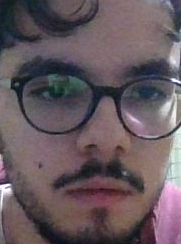

In [ ]:
# Scenario 1: Configurazione Standard (come da specifiche originali)
# Usa i default: 3 tentativi, soglie 100/20
standard_acq = BiometricAcquisition(
    max_attempts=3,
    blur_threshold=200.0,
    contrast_threshold=20,
)
face, acq_time = standard_acq.acquire_best_sample("std_face.jpg")
print(f"Acquisition time: {acq_time}")
cv2_imshow(face)